# Catalog ↔ Patch bridge

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/geotoolz/blob/main/docs/notebooks/catalog_patching.ipynb)

This notebook spans two packages: [`geocatalog`](https://github.com/jejjohnson/geocatalog)
provides the catalog, `GeoSlice`, and `CatalogDomain`; [`geopatcher`](https://github.com/jejjohnson/geopatcher)
provides the patcher framework.

A `CatalogDomain` adapts a catalog into the `Domain` shape that
`geopatcher.SpatialPatcher` consumes. Each catalog row contributes
one sub-domain; the patcher iterates them. Pairing catalogs with the
Patcher framework is how you scale tiled inference across a multi-file
archive.

In [ ]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "geocatalog @ git+https://github.com/jejjohnson/geocatalog@main",
            "geotoolz @ git+https://github.com/jejjohnson/geotoolz@main",
        ],
        check=True,
    )

In [ ]:
import tempfile
from pathlib import Path

import geocatalog as gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_bounds

## A 2x2 catalog of GeoTIFFs

In [3]:
tmp = Path(tempfile.mkdtemp(prefix="geotoolz_catpatch_"))


def write_tile(row_idx: int, col_idx: int, date_str: str, value: int) -> Path:
    CHIP, RES = 32, 10.0
    ORIGIN = (500_000, 4_000_000)
    x0 = ORIGIN[0] + col_idx * CHIP * RES
    y0 = ORIGIN[1] + row_idx * CHIP * RES
    bounds = (x0, y0, x0 + CHIP * RES, y0 + CHIP * RES)
    transform = from_bounds(*bounds, CHIP, CHIP)
    path = tmp / f"S2_T29SND_{date_str}_r{row_idx}_c{col_idx}.tif"
    data = np.full((1, CHIP, CHIP), value, dtype=np.uint16)
    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=CHIP,
        width=CHIP,
        count=1,
        dtype="uint16",
        crs="EPSG:32629",
        transform=transform,
    ) as dst:
        dst.write(data)
    return path


paths = [
    write_tile(0, 0, "20240115", value=10),
    write_tile(0, 1, "20240115", value=20),
    write_tile(1, 0, "20240115", value=30),
    write_tile(1, 1, "20240115", value=40),
]

catalog = gc.build_raster_catalog(
    paths,
    filename_regex=r"S2_T29SND_(?P<date>\d{8}).*\.tif",
    target_crs="EPSG:32629",
)
print(f"len(catalog): {len(catalog)}")
print(f"total_bounds: {catalog.total_bounds}")

len(catalog): 4
total_bounds: (500000.0, 4000000.0, 500640.0, 4000640.0)


## `CatalogDomain` — the bridge

Wrap the catalog in a `CatalogDomain` with a chosen target resolution.
Each catalog row becomes a `GeoSlice` that downstream consumers (the
patcher or your own inference loop) iterate.

In [4]:
domain = gc.CatalogDomain(catalog=catalog, resolution=(10.0, 10.0))
print(f"len(domain): {len(domain)}")
print(f"domain.bounds: {domain.bounds}")

slices = domain.slices()
for i, sl in enumerate(slices):
    print(f"  slice {i}: bounds={sl.bounds}, shape={sl.shape}")

len(domain): 4
domain.bounds: (500000.0, 4000000.0, 500640.0, 4000640.0)
  slice 0: bounds=(500000.0, 4000000.0, 500320.0, 4000320.0), shape=(32, 32)
  slice 1: bounds=(500320.0, 4000000.0, 500640.0, 4000320.0), shape=(32, 32)
  slice 2: bounds=(500000.0, 4000320.0, 500320.0, 4000640.0), shape=(32, 32)
  slice 3: bounds=(500320.0, 4000320.0, 500640.0, 4000640.0), shape=(32, 32)


## Tiled per-row inference loop

A canonical pattern: iterate the catalog's slices, load each, apply
your model, and store the result. This is the multi-file equivalent
of `Patcher.split + ApplyToChips`.

In [5]:
def model(values: np.ndarray) -> np.ndarray:
    """Trivial 'classifier' — assigns one class per tile based on the mean."""
    mean = values.mean()
    return np.full_like(values, fill_value=int(mean // 10), dtype=np.uint8)


predictions: dict[tuple, np.ndarray] = {}
for sl in domain.slices():
    chip = gc.load_raster(catalog, sl, band_indexes=[1])
    pred = model(chip.values)
    predictions[sl.bounds] = pred

print(f"produced {len(predictions)} predictions")
for bounds, pred in predictions.items():
    print(f"  {bounds[:2]}..{bounds[2:]}  →  unique class: {np.unique(pred).tolist()}")

produced 4 predictions
  (500000.0, 4000000.0)..(500320.0, 4000320.0)  →  unique class: [1]
  (500320.0, 4000000.0)..(500640.0, 4000320.0)  →  unique class: [2]
  (500000.0, 4000320.0)..(500320.0, 4000640.0)  →  unique class: [3]
  (500320.0, 4000320.0)..(500640.0, 4000640.0)  →  unique class: [4]


## Visualise the 2×2 mosaic vs predictions

mosaic.values.shape: (1, 64, 64)   # (1, 64, 64)


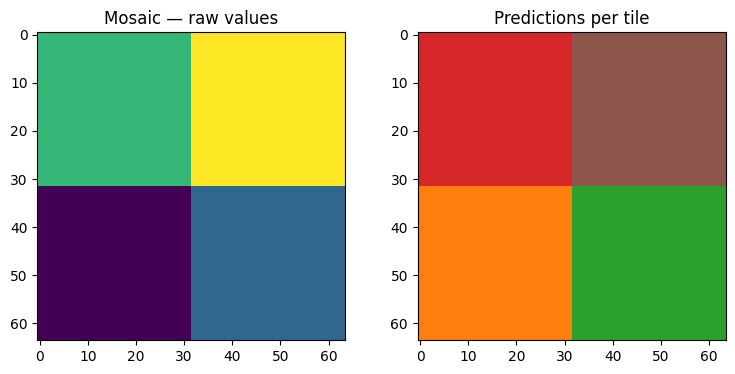

In [6]:
full_aoi = gc.GeoSlice(
    bounds=domain.bounds,
    interval=pd.Interval(
        pd.Timestamp("2024-01-15"), pd.Timestamp("2024-01-16"), closed="both"
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32629",
)
mosaic = gc.load_raster(catalog, full_aoi, band_indexes=[1])
print(f"mosaic.values.shape: {mosaic.values.shape}   # (1, 64, 64)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mosaic.values[0], cmap="viridis")
axes[0].set_title("Mosaic — raw values")
# Reconstruct the prediction mosaic by stamping each tile into a grid.
pred_grid = np.zeros((64, 64), dtype=np.uint8)
xmin, ymin = domain.bounds[0], domain.bounds[1]
for bounds, pred in predictions.items():
    col = int((bounds[0] - xmin) / 10.0)
    # Y axis is flipped: rows count from the top.
    row = int((domain.bounds[3] - bounds[3]) / 10.0)
    pred_grid[row : row + 32, col : col + 32] = pred[0]
axes[1].imshow(pred_grid, cmap="tab10", vmin=0, vmax=8)
axes[1].set_title("Predictions per tile")
plt.show()

## Why this matters

The `CatalogDomain` is the indirection that lets the same operator
pipeline work over a single in-RAM raster (via `RasterField`), a
multi-file archive (via `CatalogDomain`), or any future backend that
implements the `Domain` Protocol. Catalogs *are* a tiling for the
Patcher framework.